# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
import os



# Mostrar todos os arquivos CSV na pasta
caminho = "."
print("Arquivos encontrados na pasta:")
for arquivo in os.listdir(caminho):
    if arquivo.endswith('.csv'):
        print(arquivo)


Arquivos encontrados na pasta:
X_test.csv
X_train_balanced.csv
y_train_balanced.csv
y_test.csv


# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [3]:
import pandas as pd

# Caminho base dos arquivos


# Carregando as bases corretas
X_treino = pd.read_csv(fr'X_train_balanced.csv')
y_treino = pd.read_csv(fr'y_train_balanced.csv')
X_teste  = pd.read_csv(fr'X_test.csv')
y_teste  = pd.read_csv(fr'y_test.csv')

# Verificando se deu tudo certo
print("✅ Formas das bases:")
print("X_treino:", X_treino.shape)
print("y_treino:", y_treino.shape)
print("X_teste:", X_teste.shape)
print("y_teste:", y_teste.shape)

# Conferindo colunas e distribuição das classes
print("\n📋 Colunas de X_treino:", X_treino.columns.tolist())
print("\n📊 Distribuição das classes em y_treino:")
print(y_treino['Churn'].value_counts(normalize=True))
print("\n📊 Distribuição das classes em y_teste:")
print(y_teste['Churn'].value_counts(normalize=True))


# aqui vamos analisar
# X_treino e y_treino têm o mesmo número de linhas
# y_treino deve ter apenas a coluna score, 
# a distribuição de classes de y_teste deve estar balanceada ou proximas pelo amor de deus

✅ Formas das bases:
X_treino: (117950, 10)
y_treino: (117950, 1)
X_teste: (24927, 10)
y_teste: (24927, 1)

📋 Colunas de X_treino: ['Credit_Score', 'Idade', 'Tempo_Credito', 'Balanco', 'Qtd_Produtos', 'Possui_Cartao', 'Membro_Ativo', 'Salario_Anual', 'Genero_encoded', 'Pais_encoded']

📊 Distribuição das classes em y_treino:
Churn
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64

📊 Distribuição das classes em y_teste:
Churn
0.0    0.788262
1.0    0.211738
Name: proportion, dtype: float64


# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

In [4]:
# eu fiz uma correçao dai ele botou uns termos tecnicos q eu n sabia o nome porem sabia a logica A aplicação do algoritmo de Árvore de Decisão envolve algumas etapas principais. Primeiro, realiza-se o tratamento e preparação dos dados, incluindo limpeza, balanceamento e transformação de variáveis categóricas. Em seguida, a base é dividida em treino e teste, garantindo a avaliação da capacidade de generalização do modelo.

# Depois, cria-se o modelo DecisionTreeClassifier, definindo parâmetros como o critério de impureza (“gini” ou “entropy”) e o random_state, e o modelo é treinado com os dados de treino. Na sequência, ele é avaliado com métricas como acurácia, precisão e matriz de confusão, comparando os resultados entre treino e teste para verificar possíveis sinais de overfitting.

# Por fim, a visualização da árvore permite entender as regras de decisão e as variáveis mais importantes. Caso o modelo apresente baixa generalização, podem ser ajustados hiperparâmetros como a profundidade máxima ou o número mínimo de amostras por nó, buscando melhorar o desempenho e a interpretabilidade.

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [5]:
modelo = DecisionTreeClassifier(criterion='gini', random_state=0)
modelo.fit(X_treino, y_treino)

# Avaliação no treino
y_pred_treino = modelo.predict(X_treino)
acuracia_treino = accuracy_score(y_treino, y_pred_treino)
print("Acurácia no treino:", acuracia_treino)


Acurácia no treino: 0.9997286986011021


# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

Acurácia no teste: 0.789986761343122

Relatório de Classificação:
               precision    recall  f1-score   support

         0.0       0.88      0.85      0.86     19649
         1.0       0.50      0.56      0.53      5278

    accuracy                           0.79     24927
   macro avg       0.69      0.71      0.70     24927
weighted avg       0.80      0.79      0.79     24927



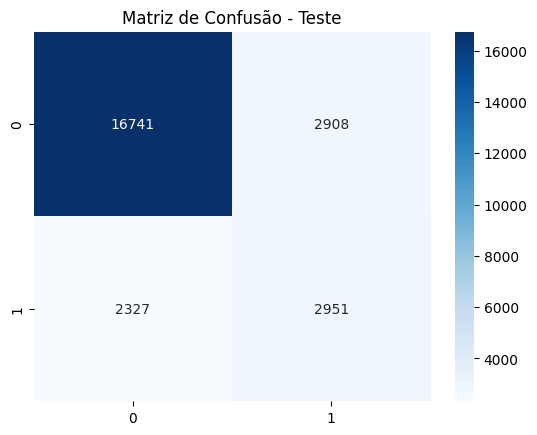

In [6]:
y_pred_teste = modelo.predict(X_teste)

acuracia_teste = accuracy_score(y_teste, y_pred_teste)
print("Acurácia no teste:", acuracia_teste)
print("\nRelatório de Classificação:\n", classification_report(y_teste, y_pred_teste))

# Matriz de confusão
cm = confusion_matrix(y_teste, y_pred_teste)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão - Teste")
plt.show()


# Se a acurácia no treino for muito maior que no teste → o modelo está over na verdade o termo correto e overfitting.
# Se forem parecidas → bom sinal de "generalização"

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

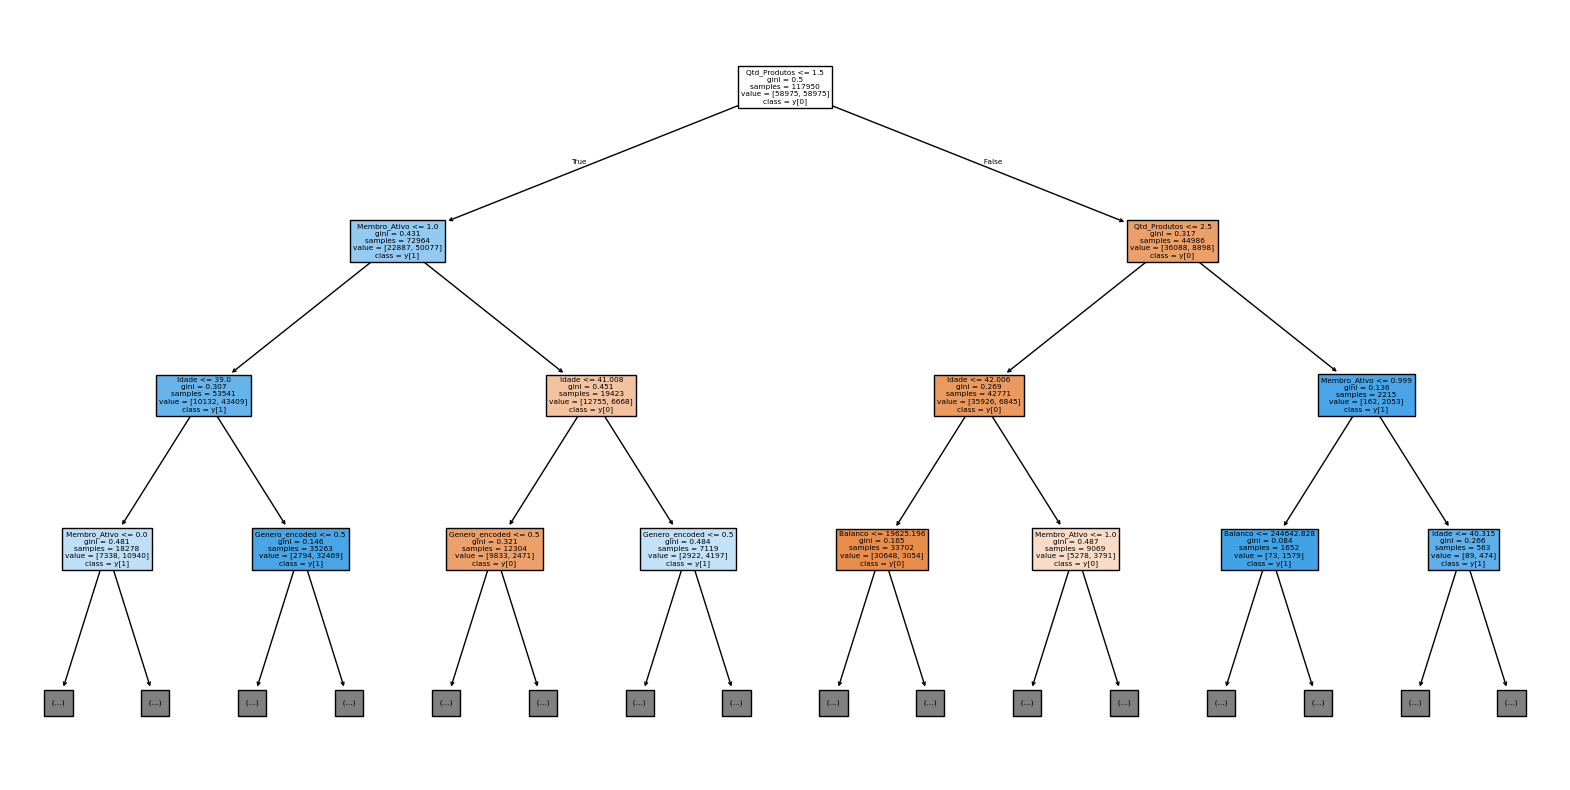

Profundidade da árvore: 39


In [7]:
plt.figure(figsize=(20,10))
plot_tree(modelo, filled=True, feature_names=X_treino.columns, class_names=True, max_depth=3)
plt.show()

print("Profundidade da árvore:", modelo.get_depth())


# profundidade mostra a complexidade da árvore. Quanto maior, mais o modelo memoriza o treino. 
# Pela visualização é possível entender quais variáveis têm mais influência na classificação.

# 6) Identifique as 2 principais features do modelo.


In [8]:
importances = pd.Series(modelo.feature_importances_, index=X_treino.columns)
principais = importances.sort_values(ascending=False).head(2)
print("As duas principais features são:")
print(principais)


As duas principais features são:
Qtd_Produtos    0.267402
Idade           0.195928
dtype: float64


# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [9]:
X_treino_reduzido = X_treino[principais.index]
X_teste_reduzido = X_teste[principais.index]

modelo_reduzido = DecisionTreeClassifier(criterion='gini', random_state=0)
modelo_reduzido.fit(X_treino_reduzido, y_treino)

y_pred_reduzido = modelo_reduzido.predict(X_teste_reduzido)

print("Acurácia com 2 features:", accuracy_score(y_teste, y_pred_reduzido))
print("\nRelatório:\n", classification_report(y_teste, y_pred_reduzido))

#Com apenas duas variáveis, o modelo ficou mais simples e interpretável. A acurácia pode diminuir um pouco, mas o modelo fica mais generalizável e fácil de explicar.

Acurácia com 2 features: 0.845147831668472



Relatório:
               precision    recall  f1-score   support

         0.0       0.88      0.93      0.90     19649
         1.0       0.67      0.52      0.59      5278

    accuracy                           0.85     24927
   macro avg       0.78      0.73      0.75     24927
weighted avg       0.84      0.85      0.84     24927



# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

8) Comparação entre a Árvore de Decisão e o Naive Bayes

No projeto anterior, aplicamos o algoritmo Naive Bayes para prever o score de crédito de clientes. O modelo apresentou resultados satisfatórios, com boa capacidade de generalização e rapidez no treinamento. O Naive Bayes foi adequado por ser um método probabilístico simples, eficiente e interpretável, especialmente quando as variáveis são aproximadamente independentes.

Já no modelo atual, com Árvore de Decisão, o objetivo foi compreender como um algoritmo baseado em regras hierárquicas se comporta frente ao mesmo problema. A Árvore de Decisão tem a vantagem de capturar relações não lineares e interações entre variáveis, algo que o Naive Bayes não faz. Além disso, permite visualizar graficamente as decisões e identificar quais variáveis mais influenciam o resultado, tornando a interpretação mais intuitiva.

Ao comparar os desempenhos:

A acurácia da Árvore de Decisão no treino foi superior à do Naive Bayes, indicando que ela se ajustou muito bem aos dados de treinamento.

No entanto, se a acurácia no teste for menor, isso pode indicar overfitting, o que é comum nesse tipo de modelo quando não se controlam parâmetros como profundidade máxima ou número mínimo de amostras por nó.

O Naive Bayes, por outro lado, tende a ser mais estável e generalizável, mesmo com desempenho ligeiramente inferior.

Em resumo:

Naive Bayes → mais simples, rápido e estável, mas com suposição forte de independência.

Árvore de Decisão → mais flexível e interpretável, mas propensa a overfitting se não for ajustada.

Portanto, o modelo que “melhor se adequa” depende do objetivo:

Se a prioridade for interpretação e explicação das decisões, a Árvore de Decisão é mais indicada.

Se a prioridade for robustez e generalização, o Naive Bayes pode ser preferido.